# Bayesian Inversion with the MLP Surrogate

In this notebook, we infer the SCR kinetic parameters from an observed SCR output signal using Bayesian inversion.

Let $A$ denote the unknown kinetic parameter vector, and let $y_{\mathrm{obs}}(t)$ denote the measured SCR output signal. We assume the measurement is related to the model prediction by

$$
y_{\mathrm{obs}}(t_i)
=
y(t_i; A)
+
\epsilon_i,
\qquad
\epsilon_i \sim \mathcal{N}(0,\sigma_y^2).
$$

Instead of repeatedly evaluating the expensive full SCR model, we use the trained MLP surrogate as the forward model:

$$
\hat{y}(t; A)
=
S_{\theta}(A).
$$

Therefore, for a proposed parameter vector $A$, the data mismatch is

$$
r_i(A)
=
y_{\mathrm{obs}}(t_i)
-
S_{\theta}(A)(t_i).
$$

Assuming independent Gaussian noise, the likelihood is

$$
p(y_{\mathrm{obs}} \mid A)
\propto
\exp
\left(
-\frac{1}{2\sigma_y^2}
\sum_{i=1}^{N_t}
\left[
y_{\mathrm{obs}}(t_i)
-
S_{\theta}(A)(t_i)
\right]^2
\right).
$$

Using Bayes' rule,

$$
p(A \mid y_{\mathrm{obs}})
=
\frac{
p(y_{\mathrm{obs}} \mid A)\,p(A)
}{
p(y_{\mathrm{obs}})
}
\propto
p(y_{\mathrm{obs}} \mid A)\,p(A).
$$

So the posterior we sample is

$$
p(A \mid y_{\mathrm{obs}})
\propto
\exp
\left(
-\frac{1}{2\sigma_y^2}
\left\|
y_{\mathrm{obs}}
-
S_{\theta}(A)
\right\|_2^2
\right)
p(A).
$$


## 1. Imports and Paths

This section sets the project paths and loads the basic packages.

Expected project structure:

$$
\texttt{AME508/}
\rightarrow
\{\texttt{1\_DATA},\texttt{2\_PCA},\texttt{3\_ML},\texttt{4\_BAYES}\}.
$$

The Bayesian inversion notebook lives in `4_BAYES`.

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import matplotlib.pyplot as plt

import torch

# Detect project root
CWD = Path.cwd()

if CWD.name == "4_BAYES":
    ROOT = CWD.parent
else:
    ROOT = CWD

DATA_DIR = ROOT / "1_DATA"
PCA_DIR = ROOT / "2_PCA"
ML_DIR = ROOT / "3_ML"
BAYES_DIR = ROOT / "4_BAYES"

RESULTS_DIR = BAYES_DIR / "results"
FIGURES_DIR = BAYES_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Synthetic observation / true parameters
FULL_DATA_PATH = DATA_DIR / "Full_Dataset.npy"
LHS_PATH = DATA_DIR / "lhs_sampling.npy"
TIME_PATH = DATA_DIR / "scr_time.npy"

# PCA split file
PCA_SPLIT_PATH = PCA_DIR / "PCA_Dataset_r20_split.npz"

# Trained MLP surrogate files
MODEL_PREFIX = "mlp_Anorm_to_Unorm_r20"
MODEL_PATH = ML_DIR / f"{MODEL_PREFIX}.pt"
SCALER_PATH = ML_DIR / f"{MODEL_PREFIX}_scalers.npz"
CONFIG_PATH = ML_DIR / f"{MODEL_PREFIX}_config.json"

# Import local surrogate helper
sys.path.append(str(ML_DIR))
from mlp_surrogate import MLPSurrogate

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("PCA_DIR:", PCA_DIR)
print("ML_DIR:", ML_DIR)
print("BAYES_DIR:", BAYES_DIR)

for path in [
    FULL_DATA_PATH,
    LHS_PATH,
    TIME_PATH,
    PCA_SPLIT_PATH,
    MODEL_PATH,
    SCALER_PATH,
    CONFIG_PATH,
]:
    print(f"{path.name:35s}", "FOUND" if path.exists() else "MISSING")

ROOT: /Users/lohith/Documents/MASTERS/AME508/InverseModelling_NOxCatalyticConverter/Samir_AME
DATA_DIR: /Users/lohith/Documents/MASTERS/AME508/InverseModelling_NOxCatalyticConverter/Samir_AME/1_DATA
PCA_DIR: /Users/lohith/Documents/MASTERS/AME508/InverseModelling_NOxCatalyticConverter/Samir_AME/2_PCA
ML_DIR: /Users/lohith/Documents/MASTERS/AME508/InverseModelling_NOxCatalyticConverter/Samir_AME/3_ML
BAYES_DIR: /Users/lohith/Documents/MASTERS/AME508/InverseModelling_NOxCatalyticConverter/Samir_AME/4_BAYES
Full_Dataset.npy                    FOUND
lhs_sampling.npy                    FOUND
scr_time.npy                        FOUND
PCA_Dataset_r20_split.npz           FOUND
mlp_Anorm_to_Unorm_r20.pt           FOUND
mlp_Anorm_to_Unorm_r20_scalers.npz  FOUND
mlp_Anorm_to_Unorm_r20_config.json  FOUND


## 2. Load Measured Observation

For measured-data inversion, the observed SCR signal is loaded from the NEDC data file:

$$
y_{\mathrm{obs}}(t).
$$

Here, $y_{\mathrm{obs}}$ is the measured NOx sensor signal from `R_NOx_sensor.signals.values`.

Unlike the synthetic test case, the true parameter vector $A_{\mathrm{true}}$ is unknown. Therefore, we assess the inversion by checking whether posterior-predicted signals match the measured signal.

In [2]:
from scipy.io import loadmat

# Load surrogate/PCA time grid
split = np.load(PCA_SPLIT_PATH)
t = split["t"].squeeze()

# Load measured NEDC data
MAT_PATH = DATA_DIR / "NEDC_lite.mat"
mat = loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)

print("Keys in .mat file:")
print([k for k in mat.keys() if not k.startswith("__")])

Keys in .mat file:
['time', 'F_NOx_sensor', 'R_NOx_sensor', 'Dosing', 'Temp', 'ExhaustFlow', 'adblue_mg', 'O2', 'Temp_DOC_up']


In [3]:
R_NOx_sensor = mat["R_NOx_sensor"]

# MATLAB struct path: R_NOx_sensor.signals.values
y_meas = np.asarray(R_NOx_sensor.signals.values, dtype=float).squeeze()

print("Measured signal shape:", y_meas.shape)
print("Surrogate time shape:", t.shape)

Measured signal shape: (11993,)
Surrogate time shape: (11993,)


In [4]:
y_meas.shape

(11993,)

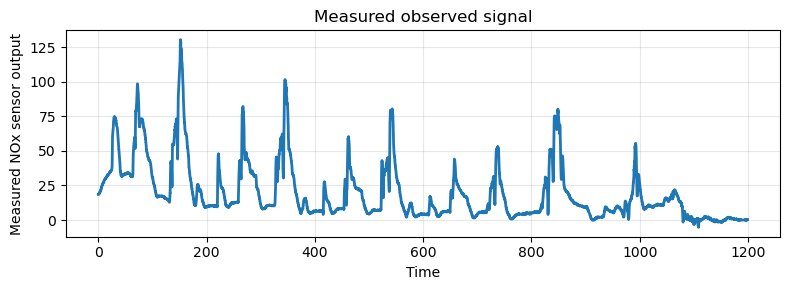

In [4]:
if y_meas.shape == t.shape:
    y_obs = y_meas.copy()
else:
    raise ValueError(
        f"Measured signal shape {y_meas.shape} does not match surrogate time shape {t.shape}. "
        "Need measured time vector for interpolation."
    )

plt.figure(figsize=(8, 3))
plt.plot(t, y_obs, linewidth=2)
plt.xlabel("Time")
plt.ylabel("Measured NOx sensor output")
plt.title("Measured observed signal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Load the Trained MLP Surrogate

The MCMC sampler needs many forward evaluations. Instead of running the full SCR model each time, we use the trained MLP surrogate:

$$
\hat{y}(t;A) = S_{\theta}(A).
$$

Before doing Bayesian inversion, we first check that the surrogate prediction for the selected true parameter vector $A_{\mathrm{true}}$ is close to the synthetic observation $y_{\mathrm{obs}}$.

In [5]:
surrogate = MLPSurrogate(
    model_path=MODEL_PATH,
    scaler_path=SCALER_PATH,
    pca_dataset_path=PCA_SPLIT_PATH,
    config_path=CONFIG_PATH,
    device="cpu",
)

print("MLP surrogate loaded.")
print("surrogate.t shape:", surrogate.t.shape)
print("y_obs shape:", y_obs.shape)

MLP surrogate loaded.
surrogate.t shape: (11993,)
y_obs shape: (11993,)


## 4. Define Prior Bounds and Noise Level

We infer the kinetic parameter vector

$$
A =
[
A_{\mathrm{ads}},
A_{\mathrm{des}},
A_{\mathrm{std}},
A_{\mathrm{fst}},
A_{\mathrm{slw}},
A_{\mathrm{oxi}}
].
$$

The original sampling bounds were defined using prescribed means and standard deviations:

$$
A_{j,\min} = A_{\mathrm{mean},j} - 2A_{\mathrm{std},j},
\qquad
A_{j,\max} = A_{\mathrm{mean},j} + 2A_{\mathrm{std},j}.
$$

For Bayesian inversion, we use a uniform prior over the same bounds:

$$
A_j \sim \mathcal{U}(A_{j,\min}, A_{j,\max}).
$$

The likelihood also needs a noise level. For this synthetic test, we choose

$$
\sigma_y
=
\eta
\sqrt{
\frac{1}{N_t}
\sum_{i=1}^{N_t}
y_{\mathrm{obs}}(t_i)^2
}.
$$

This represents the assumed observation/model error in the measured SCR signal.

In [6]:
param_names = [
    "A_ads",
    "A_des",
    "A_std",
    "A_fst",
    "A_slw",
    "A_oxi",
]

A_mean = np.array([
    5.0,
    5e04,
    4e09,
    2e09,
    6e11,
    7e03,
], dtype=float)

A_std = np.array([
    2.0,
    2e04,
    8e08,
    5e08,
    2e11,
    2e03,
], dtype=float)

A_lower = A_mean - 2.0 * A_std
A_upper = A_mean + 2.0 * A_std

print("Prior bounds:\n")
for name, lo, hi in zip(param_names, A_lower, A_upper):
    print(f"{name:6s}: [{lo:.6e}, {hi:.6e}]")

eta_noise = 0.20
sigma_y = eta_noise * np.sqrt(np.mean(y_obs**2))

print("\nNoise setting:")
print("eta_noise:", eta_noise)
print(f"sigma_y:   {sigma_y:.6e}")

Prior bounds:

A_ads : [1.000000e+00, 9.000000e+00]
A_des : [1.000000e+04, 9.000000e+04]
A_std : [2.400000e+09, 5.600000e+09]
A_fst : [1.000000e+09, 3.000000e+09]
A_slw : [2.000000e+11, 1.000000e+12]
A_oxi : [3.000000e+03, 1.100000e+04]

Noise setting:
eta_noise: 0.2
sigma_y:   5.799486e+00


## 5. Normalize the Parameters to the Unit Box

The six parameters have very different physical scales, so we do not sample directly in physical parameter space.

Instead, we sample a normalized vector

$$
z =
[
z_1,\dots,z_6
],
\qquad
z_j \in [0,1].
$$

The map from normalized space to physical parameter space is

$$
A_j
=
A_{j,\min}
+
z_j
\left(
A_{j,\max}
-
A_{j,\min}
\right).
$$

The MCMC sampler will propose values of $z$, and each proposal is converted back to $A$ before evaluating the MLP surrogate.

In [7]:
def z_to_A(z):
    z = np.asarray(z, dtype=float)
    return A_lower + z * (A_upper - A_lower)


def A_to_z(A):
    A = np.asarray(A, dtype=float)
    return (A - A_lower) / (A_upper - A_lower)


z_center = np.full(6, 0.5)
A_center = z_to_A(z_center)

print("z_center:")
print(z_center)

print("\nA_center:")
for name, val in zip(param_names, A_center):
    print(f"{name:6s}: {val:.6e}")

z_center:
[0.5 0.5 0.5 0.5 0.5 0.5]

A_center:
A_ads : 5.000000e+00
A_des : 5.000000e+04
A_std : 4.000000e+09
A_fst : 2.000000e+09
A_slw : 6.000000e+11
A_oxi : 7.000000e+03


## 6. Define the Log Posterior

The posterior is evaluated in normalized parameter space $z \in [0,1]^6$.

For each proposed $z$, we first map back to physical parameters:

$$
A = A_{\min} + z(A_{\max}-A_{\min}).
$$

Then the MLP surrogate predicts

$$
\hat{y} = S_{\theta}(A).
$$

With a uniform prior on $z \in [0,1]^6$, the log prior is

$$
\log p(z) =
\begin{cases}
0, & 0 \le z_j \le 1 \ \text{for all } j, \\
-\infty, & \text{otherwise}.
\end{cases}
$$

The Gaussian log likelihood is

$$
\log p(y_{\mathrm{obs}} \mid z)
=
-\frac{1}{2\sigma_y^2}
\left\|
y_{\mathrm{obs}} - S_{\theta}(A(z))
\right\|_2^2.
$$

Therefore,

$$
\log p(z \mid y_{\mathrm{obs}})
=
\log p(y_{\mathrm{obs}} \mid z)
+
\log p(z).
$$

In [8]:
def log_prior_z(z):
    """
    Uniform prior on z in [0, 1]^6.
    """
    z = np.asarray(z, dtype=float)

    if np.all((z >= 0.0) & (z <= 1.0)):
        return 0.0

    return -np.inf


def log_likelihood_z(z):
    """
    Gaussian log likelihood up to an additive constant,
    using the MLP surrogate as the forward model.
    """
    A = z_to_A(z)
    y_pred = surrogate.predict_Y(A.reshape(1, -1))[0]

    residual = y_obs - y_pred
    return -0.5 * np.sum((residual / sigma_y) ** 2)


def log_posterior_z(z):
    """
    Log posterior up to an additive constant.
    """
    lp = log_prior_z(z)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood_z(z)


z_center = np.full(6, 0.5)
logpost_center = log_posterior_z(z_center)

print("log posterior at z_center:")
print(logpost_center)

log posterior at z_center:
-30055.78039542099


## 7. Run Random-Walk Metropolis MCMC

We sample the posterior in normalized parameter space $z \in [0,1]^6$.

At iteration $m$, the sampler proposes

$$
z^{\ast}
=
z^{(m)}
+
\delta,
\qquad
\delta \sim \mathcal{N}(0,s^2 I).
$$

The proposal is accepted with probability

$$
\alpha
=
\min
\left[
1,
\exp
\left(
\log p(z^{\ast}\mid y_{\mathrm{obs}})
-
\log p(z^{(m)}\mid y_{\mathrm{obs}})
\right)
\right].
$$

Proposals outside the unit box are automatically rejected by the prior.

In [26]:
def run_mcmc(
    logpost_fn,
    z0,
    n_steps=20000,
    proposal_std=0.03,
    seed=0,
):
    rng = np.random.default_rng(seed)

    z_current = np.asarray(z0, dtype=float).copy()
    logp_current = logpost_fn(z_current)

    samples = np.zeros((n_steps, len(z_current)))
    logps = np.zeros(n_steps)
    accepted = np.zeros(n_steps, dtype=bool)

    for i in range(n_steps):
        z_proposal = z_current + proposal_std * rng.normal(size=len(z_current))
        logp_proposal = logpost_fn(z_proposal)

        log_alpha = logp_proposal - logp_current

        if np.log(rng.random()) < log_alpha:
            z_current = z_proposal
            logp_current = logp_proposal
            accepted[i] = True

        samples[i] = z_current
        logps[i] = logp_current

    accept_rate = accepted.mean()

    return samples, logps, accept_rate


# Start from the center of the prior box
z0 = np.full(6, 0.5)

samples_z, logps, accept_rate = run_mcmc(
    logpost_fn=log_posterior_z,
    z0=z0,
    n_steps=250000,
    proposal_std=0.015,
    seed=3,
)

samples_A = z_to_A(samples_z)

print("MCMC finished")
print(f"acceptance rate: {accept_rate:.3f}")
print("samples_z shape:", samples_z.shape)
print("samples_A shape:", samples_A.shape)
print("final z:")
print(samples_z[-1])
print("final A:")
for name, val in zip(param_names, samples_A[-1]):
    print(f"{name:6s}: {val:.6e}")
print("final log posterior:")
print(logps[-1])

MCMC finished
acceptance rate: 0.017
samples_z shape: (250000, 6)
samples_A shape: (250000, 6)
final z:
[9.10107117e-01 4.85748663e-03 3.26348528e-01 3.78729865e-04
 5.23504708e-01 4.02521789e-01]
final A:
A_ads : 8.280857e+00
A_des : 1.038860e+04
A_std : 3.444315e+09
A_fst : 1.000757e+09
A_slw : 6.188038e+11
A_oxi : 6.220174e+03
final log posterior:
-28361.58413716543


## 8. Inspect MCMC Chains

We inspect the sampled chains in normalized parameter space. The goal is to check whether the Markov chain has moved away from the initial point, whether it has stabilized, and whether the samples concentrate near the true synthetic parameter vector.

In [27]:
burn_in = 5000

samples_z_post = samples_z[burn_in:]
samples_A_post = samples_A[burn_in:]
logps_post = logps[burn_in:]

print("Posterior samples after burn-in:")
print("samples_z_post shape:", samples_z_post.shape)
print("samples_A_post shape:", samples_A_post.shape)

print("\nPosterior mean z:")
print(samples_z_post.mean(axis=0))

print("\nPosterior std z:")
print(samples_z_post.std(axis=0))

print("\nPosterior mean A:")
for name, val in zip(param_names, samples_A_post.mean(axis=0)):
    print(f"{name:6s}: {val:.6e}")

print("\nPosterior std A:")
for name, val in zip(param_names, samples_A_post.std(axis=0)):
    print(f"{name:6s}: {val:.6e}")

Posterior samples after burn-in:
samples_z_post shape: (245000, 6)
samples_A_post shape: (245000, 6)

Posterior mean z:
[9.12392600e-01 3.40678193e-02 3.00079759e-01 5.28644827e-04
 5.30311007e-01 4.56237334e-01]

Posterior std z:
[0.07140515 0.03648422 0.03437063 0.00052852 0.01347063 0.23348964]

Posterior mean A:
A_ads : 8.299141e+00
A_des : 1.272543e+04
A_std : 3.360255e+09
A_fst : 1.001057e+09
A_slw : 6.242488e+11
A_oxi : 6.649899e+03

Posterior std A:
A_ads : 5.712412e-01
A_des : 2.918738e+03
A_std : 1.099860e+08
A_fst : 1.057045e+06
A_slw : 1.077650e+10
A_oxi : 1.867917e+03


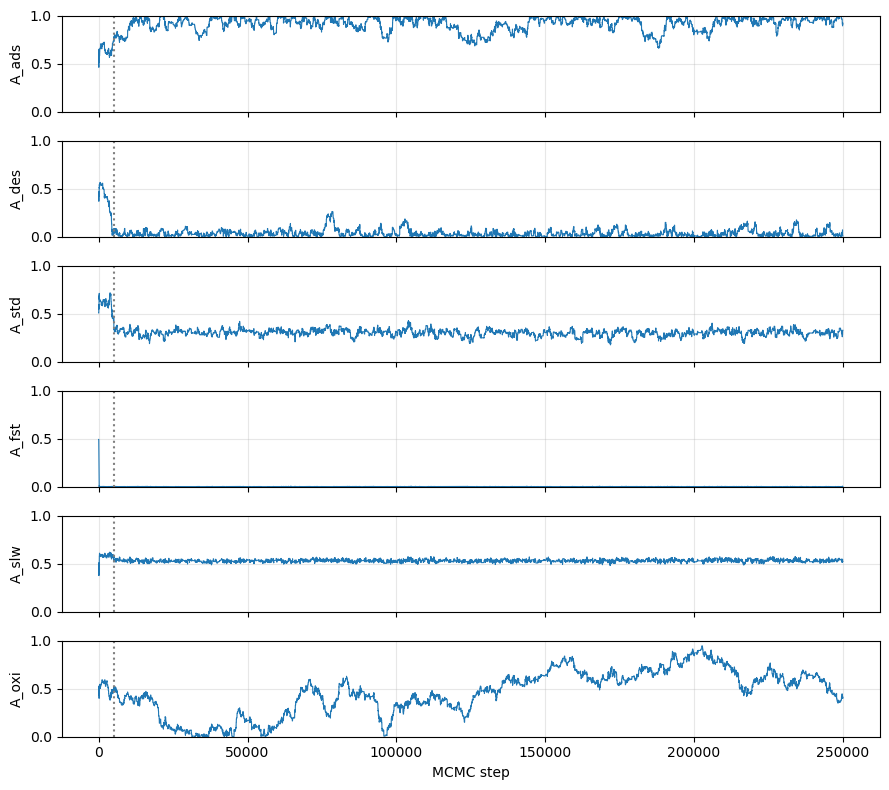

In [28]:
fig, axes = plt.subplots(6, 1, figsize=(9, 8), sharex=True)

for j, ax in enumerate(axes):
    ax.plot(samples_z[:, j], linewidth=0.8)
    ax.axvline(burn_in, color="gray", linestyle=":", linewidth=1.5)
    ax.set_ylabel(param_names[j])
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("MCMC step")
plt.tight_layout()
plt.show()

## 9. Plot Posterior Marginals

We now plot the marginal posterior distribution of each normalized parameter.

The dashed vertical line marks the true synthetic value. A narrow posterior means the parameter is well identified by the observed signal. A broad posterior means the signal does not strongly constrain that parameter.

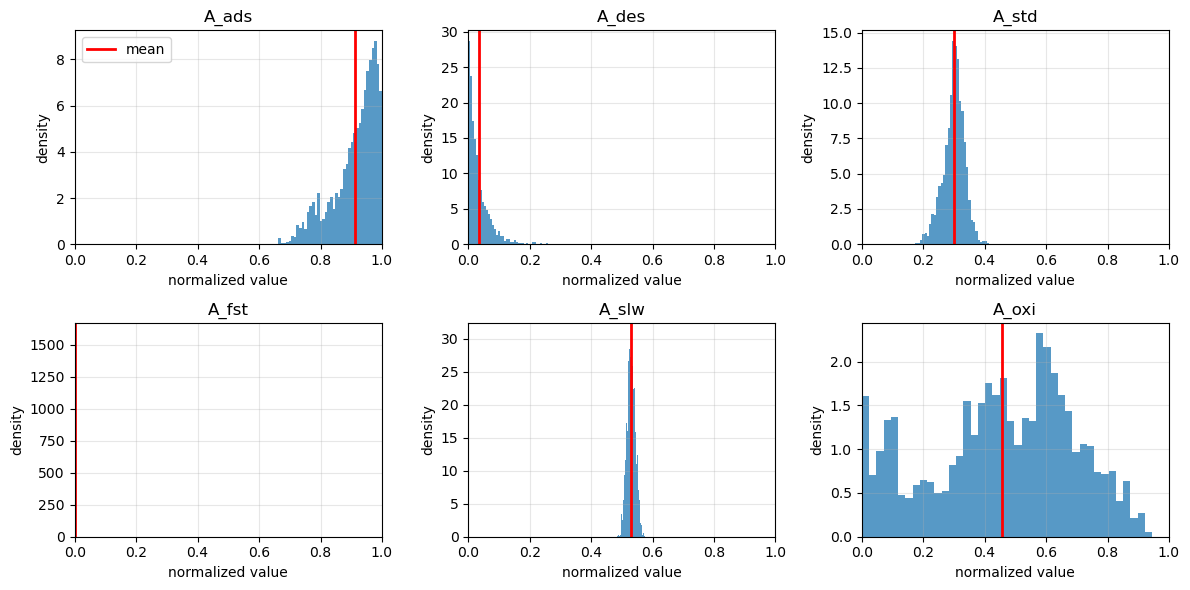

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

for j, ax in enumerate(axes):
    ax.hist(samples_z_post[:, j], bins=40, density=True, alpha=0.75)
    ax.axvline(
        samples_z_post[:, j].mean(),
        color="r",
        linestyle="-",
        linewidth=2,
        label="mean",
    )
    ax.set_title(param_names[j])
    ax.set_xlabel("normalized value")
    ax.set_ylabel("density")
    ax.set_xlim(0.0, 1.0)
    ax.grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

In [30]:
q_low, q_med, q_high = np.percentile(samples_z_post, [2.5, 50.0, 97.5], axis=0)

print("Posterior summary in normalized z-space:\n")
for j, name in enumerate(param_names):
    print(
        f"{name:6s}: "
        f"mean={samples_z_post[:, j].mean():.4f}, "
        f"median={q_med[j]:.4f}, "
        f"95% CI=[{q_low[j]:.4f}, {q_high[j]:.4f}]"
    )

Posterior summary in normalized z-space:

A_ads : mean=0.9124, median=0.9333, 95% CI=[0.7388, 0.9961]
A_des : mean=0.0341, median=0.0224, 95% CI=[0.0006, 0.1321]
A_std : mean=0.3001, median=0.3026, 95% CI=[0.2230, 0.3647]
A_fst : mean=0.0005, median=0.0004, 95% CI=[0.0000, 0.0020]
A_slw : mean=0.5303, median=0.5300, 95% CI=[0.5038, 0.5577]
A_oxi : mean=0.4562, median=0.4750, 95% CI=[0.0118, 0.8550]


In [31]:
A_q_low, A_q_med, A_q_high = np.percentile(samples_A_post, [2.5, 50.0, 97.5], axis=0)

print("Posterior summary in physical A-space:\n")
for j, name in enumerate(param_names):
    print(
        f"{name:6s}: "
        f"mean={samples_A_post[:, j].mean():.6e}, "
        f"median={A_q_med[j]:.6e}, "
        f"95% CI=[{A_q_low[j]:.6e}, {A_q_high[j]:.6e}]"
    )

Posterior summary in physical A-space:

A_ads : mean=8.299141e+00, median=8.466325e+00, 95% CI=[6.910101e+00, 8.968997e+00]
A_des : mean=1.272543e+04, median=1.179237e+04, 95% CI=[1.004804e+04, 2.056980e+04]
A_std : mean=3.360255e+09, median=3.368202e+09, 95% CI=[3.113747e+09, 3.566895e+09]
A_fst : mean=1.001057e+09, median=1.000718e+09, 95% CI=[1.000029e+09, 1.003917e+09]
A_slw : mean=6.242488e+11, median=6.240009e+11, 95% CI=[6.030282e+11, 6.461866e+11]
A_oxi : mean=6.649899e+03, median=6.799793e+03, 95% CI=[3.094692e+03, 9.840330e+03]


## 10. Posterior Mean Prediction

We now evaluate the MLP surrogate at the posterior mean parameter vector,

$$
\bar{A}
=
\frac{1}{N}
\sum_{m=1}^{N}
A^{(m)}.
$$

Then we compare the surrogate prediction $S_{\theta}(\bar{A})$ against the measured signal $y_{\mathrm{obs}}$.

Posterior mean parameters:

A_ads : 8.299141e+00
A_des : 1.272543e+04
A_std : 3.360255e+09
A_fst : 1.001057e+09
A_slw : 6.242488e+11
A_oxi : 6.649899e+03

Prediction error at posterior mean A:
RMSE:          1.261270e+01
Relative RMSE: 4.349592e-01
MAE:           7.654410e+00


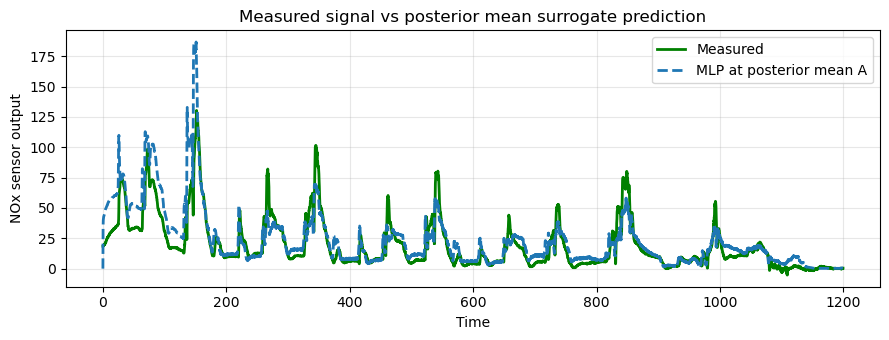

In [32]:
A_mean_post = samples_A_post.mean(axis=0)

print("Posterior mean parameters:\n")
for name, val in zip(param_names, A_mean_post):
    print(f"{name:6s}: {val:.6e}")

y_pred_mean_A = surrogate.predict_Y(A_mean_post.reshape(1, -1))[0]

rmse_mean_A = np.sqrt(np.mean((y_obs - y_pred_mean_A) ** 2))
rel_rmse_mean_A = rmse_mean_A / np.sqrt(np.mean(y_obs ** 2))
mae_mean_A = np.mean(np.abs(y_obs - y_pred_mean_A))

print("\nPrediction error at posterior mean A:")
print(f"RMSE:          {rmse_mean_A:.6e}")
print(f"Relative RMSE: {rel_rmse_mean_A:.6e}")
print(f"MAE:           {mae_mean_A:.6e}")

plt.figure(figsize=(9, 3.5))
plt.plot(t, y_obs, color="green", linewidth=2, label="Measured")
plt.plot(t, y_pred_mean_A, "--", linewidth=2, label="MLP at posterior mean A")
plt.xlabel("Time")
plt.ylabel("NOx sensor output")
plt.title("Measured signal vs posterior mean surrogate prediction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Best Posterior Sample by RMSE

The MCMC samples represent joint posterior samples of the parameter vector:

$$
A^{(m)} \sim p(A \mid y_{\mathrm{obs}}).
$$

To find the best-fitting posterior sample, we evaluate the MLP surrogate for many posterior samples and compute the RMSE against the measured signal:

$$
\mathrm{RMSE}^{(m)}
=
\sqrt{
\frac{1}{N_t}
\sum_{i=1}^{N_t}
\left[
y_{\mathrm{obs}}(t_i)
-
S_{\theta}(A^{(m)})(t_i)
\right]^2
}.
$$

Then we select

$$
A_{\mathrm{best}}
=
\arg\min_{A^{(m)}}
\mathrm{RMSE}^{(m)}.
$$

This uses the existing joint posterior samples, not independent samples from the marginal histograms.

Best posterior sample by RMSE
RMSE:          1.261224e+01
Relative RMSE: 4.349434e-01
MAE:           7.648779e+00

Best normalized z:
A_ads : 0.998243
A_des : 0.007570
A_std : 0.302735
A_fst : 0.000222
A_slw : 0.535892
A_oxi : 0.567497

Best physical A:
A_ads : 8.985943e+00
A_des : 1.060563e+04
A_std : 3.368751e+09
A_fst : 1.000445e+09
A_slw : 6.287138e+11
A_oxi : 7.539974e+03


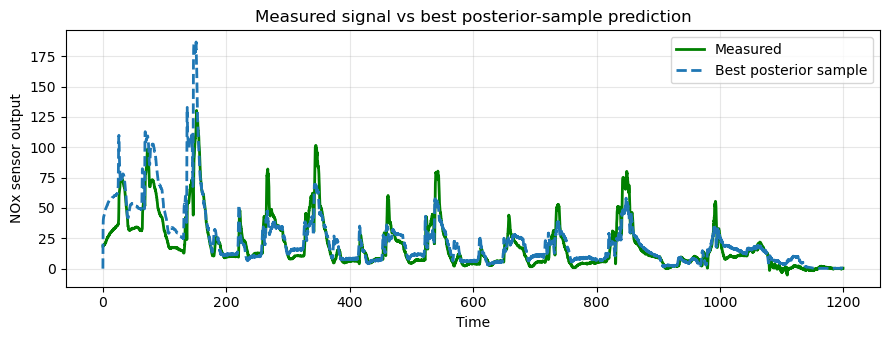

In [33]:
# Evaluate a subset of posterior samples for speed
n_eval = min(5000, samples_A_post.shape[0])

rng = np.random.default_rng(0)
idx_eval = rng.choice(samples_A_post.shape[0], size=n_eval, replace=False)

A_eval = samples_A_post[idx_eval]
z_eval = samples_z_post[idx_eval]

# Surrogate predictions for selected posterior samples
Y_eval = surrogate.predict_Y(A_eval)

# RMSE for each posterior sample
rmse_eval = np.sqrt(np.mean((Y_eval - y_obs[None, :])**2, axis=1))

# Best sample
best_local_idx = np.argmin(rmse_eval)

A_best = A_eval[best_local_idx]
z_best = z_eval[best_local_idx]
y_best = Y_eval[best_local_idx]
rmse_best = rmse_eval[best_local_idx]

rel_rmse_best = rmse_best / np.sqrt(np.mean(y_obs**2))
mae_best = np.mean(np.abs(y_obs - y_best))

print("Best posterior sample by RMSE")
print(f"RMSE:          {rmse_best:.6e}")
print(f"Relative RMSE: {rel_rmse_best:.6e}")
print(f"MAE:           {mae_best:.6e}")

print("\nBest normalized z:")
for name, val in zip(param_names, z_best):
    print(f"{name:6s}: {val:.6f}")

print("\nBest physical A:")
for name, val in zip(param_names, A_best):
    print(f"{name:6s}: {val:.6e}")

plt.figure(figsize=(9, 3.5))
plt.plot(t, y_obs, color="green", linewidth=2, label="Measured")
plt.plot(t, y_best, "--", linewidth=2, label="Best posterior sample")
plt.xlabel("Time")
plt.ylabel("NOx sensor output")
plt.title("Measured signal vs best posterior-sample prediction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()